# Avaliação de qualidade — três formas de geração de MCQs

Este notebook compara a qualidade de questões de múltipla escolha (MCQ) geradas por
**três processos diferentes**, todos sobre o mesmo domínio (operações de FPSO):

| Grupo | Como foi gerado | Fonte |
|---|---|---|
| `instruction-only` | Pipeline própria, LLM local, **sem** trecho de corpus (só instrução/assunto) | `pipeline/mcq_output/dataset_mcq_instrucao.jsonl` |
| `context-grounded` | Pipeline própria, LLM local, **com** trecho de corpus como base | `pipeline/mcq_output/dataset_mcq_petroles.jsonl` |
| `mazzuco (GPT Plus)` | Prompt manual do Mazzuco, ChatGPT Plus, 40 questões por lote | `archive/questions_mazzuco/*.docx` (4 arquivos) |

## Dimensões avaliadas

1. **Riqueza do vocabulário** — diversidade lexical dos enunciados (TTR e MSTTR).
2. **"Chutabilidade" pelo enunciado** — o quanto a resposta correta é semanticamente
   parecida com o comando da questão em relação aos distratores (pista de atalho).
3. **Qualidade dos distratores** — quão semanticamente próximos os distratores estão
   da resposta correta (distrator bom é plausível, não óbvio de eliminar).
4. **Viés de tamanho** — se a alternativa mais longa (ou, simetricamente, a mais
   curta) tende a ser a correta.
5. **Clareza/legibilidade do enunciado** — não existe uma métrica consagrada de
   legibilidade para português técnico; usamos como *proxy* o Flesch Reading Ease
   adaptado para PT-BR e estatísticas de complexidade sintática (palavras/frase,
   sílabas/palavra), deixando claras as limitações.

Similaridades semânticas usam embeddings de frase (`paraphrase-multilingual-MiniLM-L12-v2`,
já usado em outras partes do pipeline), não apenas sobreposição lexical.

In [1]:
import json
import re
import unicodedata
from pathlib import Path

import docx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textstat
from docx.oxml.ns import qn
from sklearn.metrics.pairwise import cosine_similarity

textstat.set_lang("pt_BR")

# Ajuste este caminho se o repositório estiver em outro lugar.
ROOT = Path("/home/rodrigo.flexa/MCQ_CONTEXT_GEN")
MCQ_OUTPUT = ROOT / "pipeline/mcq_output"
MAZZUCO_DIR = ROOT / "archive/questions_mazzuco"

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110

## 1. Leitura e unificação dos dados

Os DOCX do Mazzuco não têm um formato único — cada arquivo foi produzido em uma
sessão de prompt diferente, então a questão, as alternativas e o gabarito ora
aparecem em parágrafos, ora em tabelas. O parser abaixo é tolerante a essas
variações: ele varre parágrafos e tabelas **na ordem em que aparecem no corpo do
documento** e reconhece os padrões observados nos 4 arquivos.

In [2]:
ALT_LETTERS = {"A", "B", "C", "D"}
DIFF_MAP = {
    "facil": "facil", "media": "media", "dificil": "dificil",
}


def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")


def norm_diff(s):
    if not s:
        return None
    key = strip_accents(s.strip().lower()).rstrip(".")
    return DIFF_MAP.get(key)


def iter_block_items(doc):
    """Percorre parágrafos e tabelas na ordem em que aparecem no corpo do documento."""
    body = doc.element.body
    for child in body.iterchildren():
        if child.tag == qn("w:p"):
            yield "p", docx.text.paragraph.Paragraph(child, doc)
        elif child.tag == qn("w:tbl"):
            yield "tbl", docx.table.Table(child, doc)


def classify_table(table):
    rows = [[c.text.strip() for c in row.cells] for row in table.rows]
    first_cells = [r[0] if r else "" for r in rows]
    joined = " ".join(" ".join(r) for r in rows)

    if any(re.search(r"quest[aã]o\s*\d+", c, re.IGNORECASE) for c in first_cells):
        return "header", rows
    if "Aprovar" in joined and "Descartar" in joined:
        return "ignore", rows
    if len(rows) == 4 and all(r and r[0].strip().upper() in ALT_LETTERS for r in rows):
        return "alternatives", rows
    # A chave pode vir em coluna própria ("Gabarito" | "C") ou embutida numa só
    # célula ("Gabarito: C") -- normaliza cortando tudo a partir do ":" antes de comparar.
    keys_norm = [strip_accents(c.split(":", 1)[0].lower()).strip() for c in first_cells]
    if any(k in ("gabarito", "resposta correta") for k in keys_norm):
        return "metadata", rows
    if (len(rows) == 1 and len(rows[0]) >= 4
            and strip_accents(rows[0][0].lower()) == "dificuldade"
            and strip_accents(rows[0][2].lower()) == "tema"):
        return "diff_tema", rows
    return "ignore", rows


def parse_mazzuco_docx(path):
    """Extrai (stem, alternativas, gabarito, dificuldade, tema, justificativa) de um DOCX do Mazzuco."""
    doc = docx.Document(str(path))
    questions = []
    cur_stem, cur_alts, cur_meta = [], {}, {}
    have_started = False
    meta_done = False

    def flush():
        if not have_started:
            return
        stem = " ".join(s for s in cur_stem if s).strip()
        alts = [cur_alts.get(L, "") for L in "ABCD"]
        gabarito = (cur_meta.get("gabarito") or "").strip().upper()
        # ATENÇÃO: usar `gabarito in ALT_LETTERS` (set), não `gabarito in "ABCD"`
        # (string) -- string vazia é substring de qualquer string, então o teste
        # errado aceitava gabarito ausente como se fosse "A" (índice 0).
        idx = "ABCD".index(gabarito) if gabarito in ALT_LETTERS else None
        if stem and all(alts) and idx is not None:
            questions.append({
                "stem": stem, "alternatives": alts, "correct_answer_index": idx,
                "difficulty": norm_diff(cur_meta.get("dificuldade")),
                "correct_reason": cur_meta.get("correct_reason"),
                "source_file": path.name,
            })

    for kind, item in iter_block_items(doc):
        if kind == "p":
            text = item.text.strip()
            if not text:
                continue
            if re.match(r"^quest[aã]o\s*\d+\b", text, re.IGNORECASE):
                flush()
                cur_stem, cur_alts, cur_meta = [], {}, {}
                have_started, meta_done = True, False
                continue
            if "CURADORIA" in text.upper() or re.match(r"^notas de curadoria", text, re.IGNORECASE):
                continue
            if re.match(r"^alternativas?\s*:?$", text, re.IGNORECASE):
                continue
            if re.match(r"^subtema\s*:", text, re.IGNORECASE):
                continue
            am = re.match(r"^([A-D])[\.\)]\s*(.+)$", text)
            if am:
                cur_alts[am.group(1)] = am.group(2).strip()
                continue
            if not cur_alts:
                text = re.sub(r"^enunciado\s*:\s*", "", text, flags=re.IGNORECASE)
                cur_stem.append(text)
        else:  # tabela
            ttype, rows = classify_table(item)
            if ttype == "header":
                flush()
                cur_stem, cur_alts, cur_meta = [], {}, {}
                have_started, meta_done = True, False
                for r in rows:
                    for cell in r:
                        d = norm_diff(cell)
                        if d:
                            cur_meta["dificuldade"] = d
            elif ttype == "diff_tema":
                cur_meta["dificuldade"] = norm_diff(rows[0][1])
            elif ttype == "alternatives":
                for r in rows:
                    cur_alts[r[0].strip().upper()] = r[1].strip() if len(r) > 1 else ""
            elif ttype == "metadata" and not meta_done:
                meta_done = True
                for r in rows:
                    if len(r) >= 2:
                        key, val = r[0], r[1]
                    else:
                        parts = r[0].split(":", 1)
                        key, val = (parts[0], parts[1]) if len(parts) == 2 else (r[0], "")
                    kn = strip_accents(key.lower()).rstrip(":").strip()
                    if kn in ("gabarito", "resposta correta"):
                        cur_meta["gabarito"] = val.strip()
                    elif kn in ("dificuldade", "grau de dificuldade"):
                        cur_meta["dificuldade"] = norm_diff(val)
                    elif kn in ("correct_reason", "justificativa"):
                        cur_meta["correct_reason"] = val.split("\n")[0].strip()
            # "ignore" -> tabelas de resumo/curadoria, descartadas
    flush()
    return questions

In [3]:
FILENAME_TOPIC = {
    "Questionario_Medicao_Fiscal_FPSO_40_questoes.docx": "medicao_fiscal_offloading",
    "Questoes_Captacao_Tratamento_Injecao_Agua_Mar_FPSO_40.docx": "injecao_agua_mar",
    "Questoes_Produtos_Quimicos_FPSO_40.docx": "produtos_quimicos",
    "Questoes_Tratamento_Agua_Produzida_FPSO_40.docx": "tratamento_agua_produzida",
}

rows = []
for fn, topic in FILENAME_TOPIC.items():
    qs = parse_mazzuco_docx(MAZZUCO_DIR / fn)
    assert len(qs) == 40, f"{fn}: esperado 40 questões, obtido {len(qs)}"
    for q in qs:
        q["topic"] = topic
        rows.append(q)
df_mazzuco = pd.DataFrame(rows)
df_mazzuco["grupo"] = "mazzuco (GPT Plus)"
print(f"Mazzuco: {len(df_mazzuco)} questões em {df_mazzuco['source_file'].nunique()} arquivos")


def load_jsonl(path):
    return pd.DataFrame([json.loads(l) for l in open(path, encoding="utf-8")])


df_ins = load_jsonl(MCQ_OUTPUT / "dataset_mcq_instrucao.jsonl")
df_ctx = load_jsonl(MCQ_OUTPUT / "dataset_mcq_petroles.jsonl")
df_ins["grupo"] = "instruction-only"
df_ctx["grupo"] = "context-grounded"
print(f"Instruction-only: {len(df_ins)} questões | Context-grounded: {len(df_ctx)} questões")

COLS = ["grupo", "topic", "stem", "alternatives", "correct_answer_index", "difficulty", "correct_reason"]
df_all = pd.concat([df_ins[COLS], df_ctx[COLS], df_mazzuco[COLS]], ignore_index=True)
df_all["n_alt"] = df_all["alternatives"].apply(len)
assert (df_all["n_alt"] == 4).all(), "todas as questões devem ter 4 alternativas"
df_all["grupo"] = pd.Categorical(
    df_all["grupo"], categories=["instruction-only", "context-grounded", "mazzuco (GPT Plus)"], ordered=True
)
df_all.head(3)

Mazzuco: 160 questões em 4 arquivos
Instruction-only: 50 questões | Context-grounded: 51 questões


,grupo,topic,stem,alternatives,correct_answer_index,difficulty,correct_reason,n_alt
0,instruction-only,gestao_desempenho,"Durante a fase de planejamento operacional de um FPSO, a equipe identifica q...","[Investigar gargalos nos processos operacionais, como eficiência de separaçã...",0,facil,"Se a confiabilidade dos ativos (equipamentos) está ok, a perda de produção p...",4
1,instruction-only,gestao_desempenho,"Ao analisar os indicadores de perdas de produção de um FPSO, nota-se que as ...","[Focar exclusivamente na redução das paradas de manutenção, pois elas repres...",1,dificil,"Gestão de desempenho não olha apenas para o tempo (uptime), mas para o impac...",4
2,instruction-only,gestao_desempenho,A gestão de indicadores de um FPSO revela que a taxa de falhas de bombas de ...,[Aumentar a frequência de manutenção preventiva das bombas para substituir o...,2,media,Tratar o sintoma (falha da bomba) com manutenção (opção C) ou filtros (opção...,4


> **Nota de correção de dados (2026-08-20):** o parser tinha um bug que afetava
> só o arquivo `Questoes_Produtos_Quimicos_FPSO_40.docx` — ele usa um formato de
> tabela de gabarito diferente dos outros 3 arquivos (`"Gabarito: C"` numa única
> célula, em vez de duas colunas), que `classify_table` não reconhecia. Quando a
> extração do gabarito falhava, o fallback `"ABCD".index(gabarito) if gabarito in
> "ABCD" else None` testava substring numa **string**, não pertencimento a um
> **conjunto** — e string vazia é substring de qualquer string, então as 40
> questões desse arquivo caíam silenciosamente em `correct_answer_index = 0`
> ("A") em vez de serem descartadas. Isso inflava artificialmente `pct_gabarito_A`
> do Mazzuco (~44% observado antes da correção) e corrompia todas as métricas de
> corretude (viés de tamanho, chutabilidade, distratores) para esse tópico.
> Corrigido em `classify_table` (chave normalizada cortando no `:`) e no fallback
> (`gabarito in ALT_LETTERS`, um `set`). Distribuição real do gabarito nesse
> arquivo, confirmada por extração independente: A:10 B:10 C:10 D:10.

## 2. Visão geral do dataset unificado

In [4]:
overview = df_all.groupby("grupo", observed=True).agg(
    n_questoes=("stem", "size"),
    n_assuntos=("topic", "nunique"),
    facil=("difficulty", lambda s: (s == "facil").sum()),
    media=("difficulty", lambda s: (s == "media").sum()),
    dificil=("difficulty", lambda s: (s == "dificil").sum()),
)
overview

,n_questoes,n_assuntos,facil,media,dificil
grupo,,,,,
instruction-only,50,5,16,22,12
context-grounded,51,5,7,25,19
mazzuco (GPT Plus),160,4,48,64,48


## 3. Riqueza do vocabulário

Duas medidas de diversidade lexical sobre os enunciados (palavras de conteúdo,
≥3 letras, sem stopwords):

- **TTR** (*type-token ratio*) global: nº de palavras únicas ÷ nº total de palavras.
  É mecanicamente puxado para baixo por corpora maiores, então também calculamos:
- **MSTTR** (*mean segmental TTR*): o corpus é dividido em janelas de tamanho fixo
  (300 palavras) e a TTR é calculada e depois **promediada** por janela — isso
  neutraliza o efeito do tamanho do corpus e permite comparar grupos com números
  diferentes de questões (50 vs. 51 vs. 160) de forma mais justa.

In [5]:
STOP = set(
    "que nao com para por uma dos das mais como ser sao esta deve devem qual "
    "quais sobre entre este esta esses essas pelo pela pelos pelas seu sua "
    "seus suas ele ela eles elas isso essa esse".split()
)


def content_tokens(text):
    norm = strip_accents(str(text).lower())
    return [w for w in re.findall(r"[a-z]{3,}", norm) if w not in STOP]


def msttr(tokens, window=300):
    if len(tokens) < window:
        return len(set(tokens)) / max(len(tokens), 1)
    scores = [
        len(set(tokens[i:i + window])) / window
        for i in range(0, len(tokens) - window + 1, window)
    ]
    return float(np.mean(scores))


vocab_rows = []
for grupo, d in df_all.groupby("grupo", observed=True):
    toks = [t for stem in d["stem"] for t in content_tokens(stem)]
    per_q_unique = d["stem"].apply(lambda s: len(set(content_tokens(s))))
    per_q_words = d["stem"].apply(lambda s: len(content_tokens(s)))
    vocab_rows.append({
        "grupo": grupo,
        "n_palavras_conteudo": len(toks),
        "vocabulario_unico": len(set(toks)),
        "TTR_global": round(len(set(toks)) / max(len(toks), 1), 3),
        "MSTTR_300": round(msttr(toks, 300), 3),
        "palavras_conteudo/enunciado": round(per_q_words.mean(), 1),
        "unicas/enunciado": round(per_q_unique.mean(), 1),
    })
df_vocab = pd.DataFrame(vocab_rows).set_index("grupo")
df_vocab

,n_palavras_conteudo,vocabulario_unico,TTR_global,MSTTR_300,palavras_conteudo/enunciado,unicas/enunciado
grupo,,,,,,
instruction-only,1548,717,0.463,0.683,31.0,28.9
context-grounded,2450,938,0.383,0.680,48.0,44.7
mazzuco (GPT Plus),2891,1138,0.394,0.753,18.1,17.8


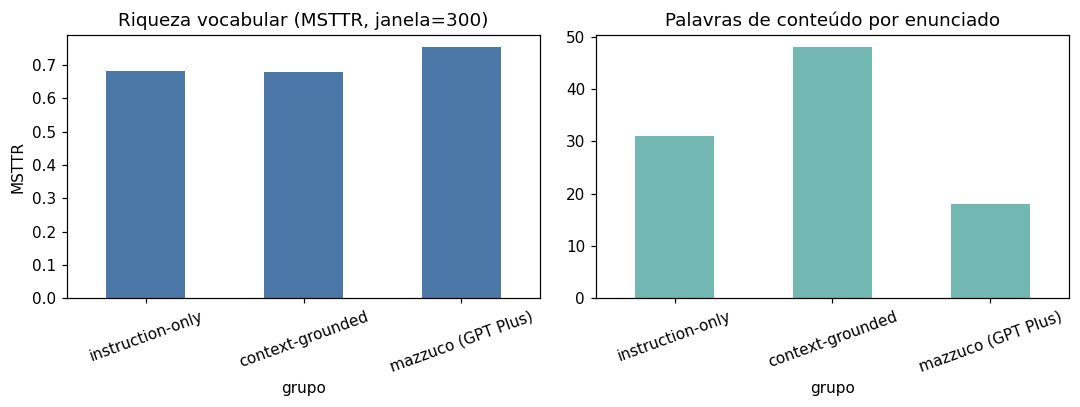

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
df_vocab["MSTTR_300"].plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Riqueza vocabular (MSTTR, janela=300)")
axes[0].set_ylabel("MSTTR")
axes[0].tick_params(axis="x", rotation=20)

df_vocab["palavras_conteudo/enunciado"].plot(kind="bar", ax=axes[1], color="#72b7b2")
axes[1].set_title("Palavras de conteúdo por enunciado")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 4. Viés de tamanho — "a alternativa mais longa é a correta"?

Vício clássico de MCQ gerada por LLM: a resposta certa é escrita com mais cuidado
e fica mais longa que os distratores, permitindo chutar sem ler o conteúdo. Se o
gabarito fosse independente do tamanho, a alternativa mais longa deveria ser a
correta em ~25% das questões (1 em cada 4). Também checamos o vício simétrico —
a alternativa **mais curta** ser a correta — pelo mesmo motivo: se o gerador
escreve distratores mais longos/elaborados que a resposta certa, o gabarito
também vira "chutável" pelo tamanho, só que na direção oposta.

In [7]:
def n_words(s):
    return len(re.findall(r"\w+", str(s)))


def length_bias_row(row):
    lens = [n_words(a) for a in row["alternatives"]]
    ci = row["correct_answer_index"]
    longest_idx = int(np.argmax(lens))
    shortest_idx = int(np.argmin(lens))
    others = [l for i, l in enumerate(lens) if i != ci]
    ratio = lens[ci] / (np.mean(others) + 1e-9)
    return pd.Series({
        "maior_e_correta": longest_idx == ci,
        "menor_e_correta": shortest_idx == ci,
        "razao_tam_correta_distratores": ratio,
    })


bias = df_all.apply(length_bias_row, axis=1)
df_all["maior_e_correta"] = bias["maior_e_correta"]
df_all["menor_e_correta"] = bias["menor_e_correta"]
df_all["razao_tam_correta_distratores"] = bias["razao_tam_correta_distratores"]
df_bias = pd.concat([df_all[["grupo"]], bias], axis=1)

tam_summary = df_bias.groupby("grupo", observed=True).agg(
    pct_maior_e_correta=("maior_e_correta", "mean"),
    pct_menor_e_correta=("menor_e_correta", "mean"),
    razao_media=("razao_tam_correta_distratores", "mean"),
)
tam_summary["pct_maior_e_correta"] = (tam_summary["pct_maior_e_correta"] * 100).round(1)
tam_summary["pct_menor_e_correta"] = (tam_summary["pct_menor_e_correta"] * 100).round(1)
tam_summary["razao_media"] = tam_summary["razao_media"].round(2)
tam_summary

,pct_maior_e_correta,pct_menor_e_correta,razao_media
grupo,,,
instruction-only,86.0,2.0,1.29
context-grounded,66.7,5.9,1.14
mazzuco (GPT Plus),21.9,26.9,0.99


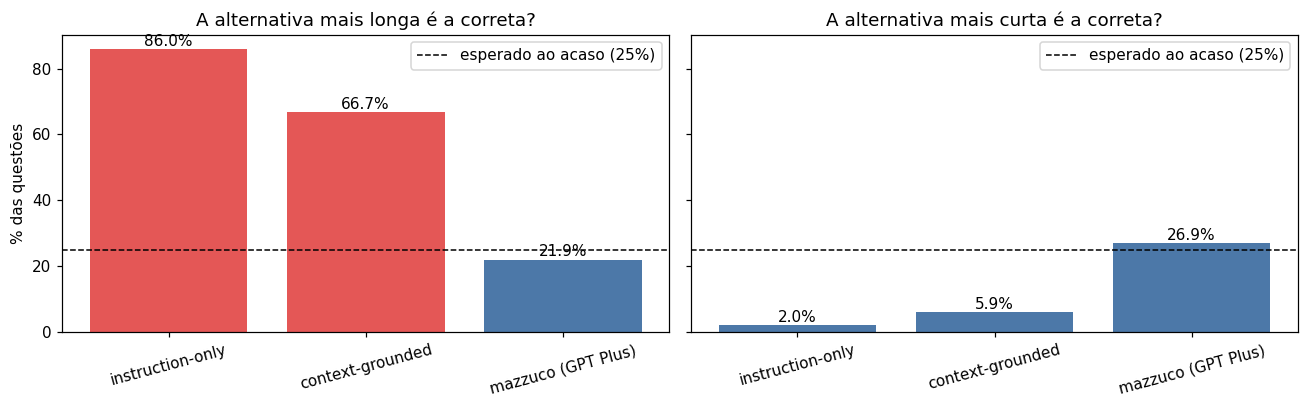

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)

for ax, col, title in [
    (axes[0], "pct_maior_e_correta", "A alternativa mais longa é a correta?"),
    (axes[1], "pct_menor_e_correta", "A alternativa mais curta é a correta?"),
]:
    vals = tam_summary[col]
    colors = ["#e45756" if v > 33 else "#4c78a8" for v in vals]
    bars = ax.bar(vals.index.astype(str), vals.values, color=colors)
    ax.axhline(25, color="k", ls="--", lw=1, label="esperado ao acaso (25%)")
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis="x", rotation=15)

axes[0].set_ylabel("% das questões")
plt.tight_layout(); plt.show()

### Distribuição do tamanho das alternativas

Este gráfico detalha o viés de tamanho: alternativas corretas e distratores são
comparados pela quantidade de palavras. A sobreposição facilita ver se as corretas
ficam deslocadas para a direita, como no exemplo de referência.

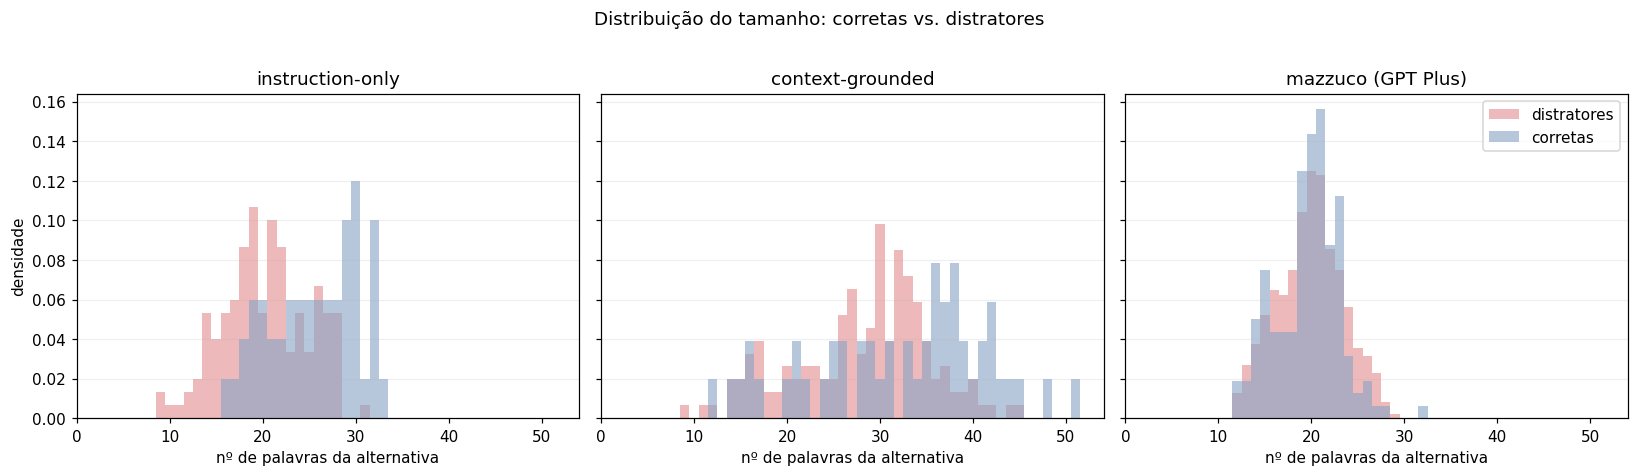

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
bins = np.arange(0.5, max(df_all["alternatives"].map(lambda alts: max(n_words(a) for a in alts))) + 1.5, 1)

for ax, (grupo, d) in zip(axes, df_all.groupby("grupo", observed=True)):
    correct_words = [
        n_words(row["alternatives"][row["correct_answer_index"]])
        for _, row in d.iterrows()
    ]
    distractor_words = [
        n_words(alt)
        for _, row in d.iterrows()
        for i, alt in enumerate(row["alternatives"])
        if i != row["correct_answer_index"]
    ]

    ax.hist(distractor_words, bins=bins, density=True, alpha=0.62,
            color="#e58f91", label="distratores")
    ax.hist(correct_words, bins=bins, density=True, alpha=0.62,
            color="#89a5c7", label="corretas")
    ax.set_title(str(grupo))
    ax.set_xlabel("nº de palavras da alternativa")
    ax.set_xlim(left=0)
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel("densidade")
axes[-1].legend(loc="upper right")
fig.suptitle("Distribuição do tamanho: corretas vs. distratores", y=1.02)
plt.tight_layout(); plt.show()

## 5. Similaridade semântica enunciado ↔ alternativas

Usamos embeddings (`paraphrase-multilingual-MiniLM-L12-v2`) em vez de sobreposição
de palavras, porque um enunciado pode "entregar" a resposta por sinônimos e
paráfrases, não só por repetição literal de termos.

Para cada questão calculamos a similaridade de cosseno entre o **enunciado** e
cada uma das 4 alternativas. Isso alimenta duas métricas:

- **Chutabilidade (seção 6)**: a resposta correta é a alternativa mais parecida
  com o enunciado com mais frequência do que o acaso (25%)?
- **Qualidade dos distratores (seção 7)**: quão parecidos os distratores são da
  **resposta correta** (não do enunciado) — distratores bons ficam no mesmo campo
  semântico da resposta certa, sem serem óbvios de descartar.

In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

all_texts = list(df_all["stem"]) + [a for alts in df_all["alternatives"] for a in alts]
unique_texts = list(dict.fromkeys(all_texts))
embeddings = model.encode(unique_texts, show_progress_bar=True, batch_size=64)
emb_lookup = dict(zip(unique_texts, embeddings))

stem_emb = np.vstack(df_all["stem"].map(emb_lookup))
alt_embs = np.stack([
    [emb_lookup[a] for a in alts] for alts in df_all["alternatives"]
])  # (n_questoes, 4, dim)

# similaridade enunciado x cada alternativa
sims_stem_alt = np.einsum("nd,nad->na", stem_emb, alt_embs) / (
    np.linalg.norm(stem_emb, axis=1, keepdims=True)
    * np.linalg.norm(alt_embs, axis=2)
)
print("sims_stem_alt shape:", sims_stem_alt.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

sims_stem_alt shape: (261, 4)


## 6. Chutabilidade — a resposta correta "combina demais" com o enunciado?

`gap_semantico` = similaridade(enunciado, correta) − média[similaridade(enunciado, distratores)].
Valores positivos e altos indicam que dá para apontar a correta só pela proximidade
semântica com o comando da questão, sem entender o conteúdo técnico.

In [11]:
correct_idx = df_all["correct_answer_index"].to_numpy()
n = len(df_all)
sim_correct = sims_stem_alt[np.arange(n), correct_idx]
mask_distractor = np.ones_like(sims_stem_alt, dtype=bool)
mask_distractor[np.arange(n), correct_idx] = False
sim_distractors_mean = (sims_stem_alt * mask_distractor).sum(axis=1) / 3

df_all["sim_stem_correta"] = sim_correct
df_all["sim_stem_distratores_media"] = sim_distractors_mean
df_all["gap_semantico"] = sim_correct - sim_distractors_mean
df_all["correta_e_mais_similar_ao_enunciado"] = sims_stem_alt.argmax(axis=1) == correct_idx

chuta_summary = df_all.groupby("grupo", observed=True).agg(
    pct_correta_mais_similar=("correta_e_mais_similar_ao_enunciado", "mean"),
    gap_semantico_medio=("gap_semantico", "mean"),
)
chuta_summary["pct_correta_mais_similar"] = (chuta_summary["pct_correta_mais_similar"] * 100).round(1)
chuta_summary["gap_semantico_medio"] = chuta_summary["gap_semantico_medio"].round(3)
chuta_summary

,pct_correta_mais_similar,gap_semantico_medio
grupo,,
instruction-only,34.0,0.008
context-grounded,27.5,0.017
mazzuco (GPT Plus),30.6,0.018


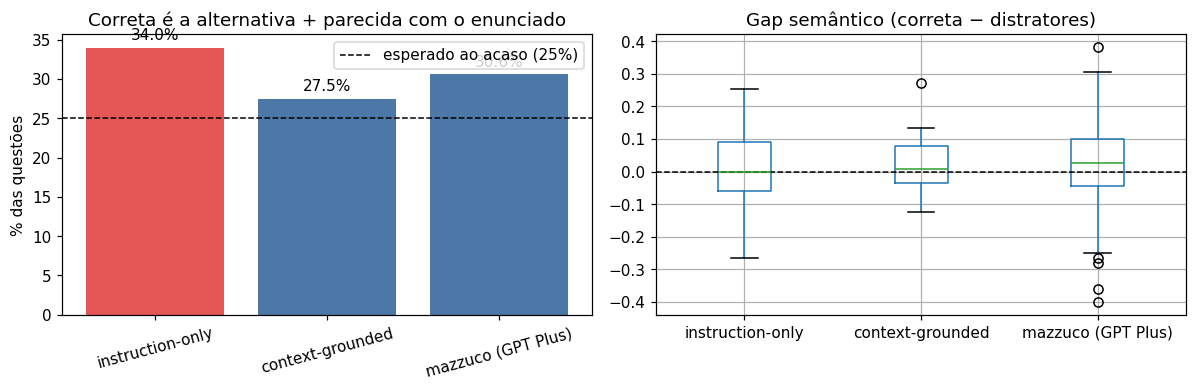

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

vals = chuta_summary["pct_correta_mais_similar"]
colors = ["#e45756" if v > 33 else "#4c78a8" for v in vals]
bars = axes[0].bar(vals.index.astype(str), vals.values, color=colors)
axes[0].axhline(25, color="k", ls="--", lw=1, label="esperado ao acaso (25%)")
for b, v in zip(bars, vals.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center")
axes[0].set_ylabel("% das questões")
axes[0].set_title("Correta é a alternativa + parecida com o enunciado")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=15)

df_all.boxplot(column="gap_semantico", by="grupo", ax=axes[1])
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_title("Gap semântico (correta − distratores)")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 7. Qualidade dos distratores — similaridade com a resposta correta

Para cada questão, medimos a similaridade de cosseno entre a **resposta correta**
e cada **distrator**. Um bom distrator fica plausível (não muito distante
semanticamente da correta), mas ainda assim está errado. Distratores com
similaridade muito baixa tendem a ser "óbvios de eliminar" — o inverso do vício
clássico de distrator-lixo, mas medido por semântica em vez de tamanho.

In [13]:
sim_correct_alt = np.einsum("nd,nad->na", alt_embs[np.arange(n), correct_idx], alt_embs) / (
    np.linalg.norm(alt_embs[np.arange(n), correct_idx], axis=1, keepdims=True)
    * np.linalg.norm(alt_embs, axis=2)
)
sim_correct_distractors = sim_correct_alt[mask_distractor].reshape(n, 3)

df_all["sim_correta_distratores_media"] = sim_correct_distractors.mean(axis=1)
df_all["sim_correta_distrator_min"] = sim_correct_distractors.min(axis=1)

distrator_summary = df_all.groupby("grupo", observed=True).agg(
    sim_media_correta_distratores=("sim_correta_distratores_media", "mean"),
    sim_minima_media=("sim_correta_distrator_min", "mean"),
).round(3)
distrator_summary

,sim_media_correta_distratores,sim_minima_media
grupo,,
instruction-only,0.475,0.390
context-grounded,0.511,0.435
mazzuco (GPT Plus),0.421,0.323


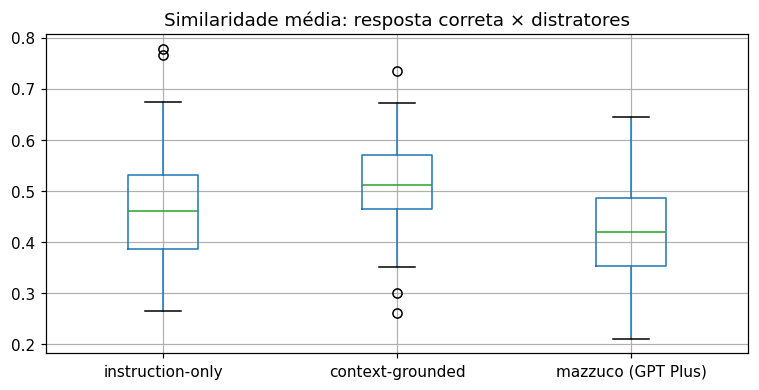

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.8))
df_all.boxplot(column="sim_correta_distratores_media", by="grupo", ax=ax)
ax.set_title("Similaridade média: resposta correta × distratores")
ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 8. Clareza do enunciado (legibilidade) — proxy, com ressalvas

**Não existe uma métrica consagrada de legibilidade para português técnico.** As
fórmulas clássicas (Flesch, Gunning Fog etc.) foram calibradas para textos gerais
em inglês; a adaptação para PT-BR (usada aqui via `textstat`, `lang="pt_BR"`) é
uma aproximação e tende a penalizar texto técnico com termos longos e jargão
(ex.: "cromatógrafo", "metrologicamente") mesmo quando o enunciado é claro para
quem conhece o domínio. Por isso reportamos o Flesch Reading Ease **ao lado** de
métricas mais transparentes (palavras/frase, sílabas/palavra) — a leitura deve
ser comparativa entre grupos, não como nota absoluta de qualidade.

- **Flesch Reading Ease (pt)**: maior = mais fácil de ler (escala ~0–100).
- **Palavras/frase**: enunciados com múltiplas orações subordinadas (cenários
  complexos) tendem a ter frases mais longas — nem sempre ruim, mas correlaciona
  com esforço de leitura.

In [15]:
def readability_row(stem):
    try:
        words = textstat.lexicon_count(stem)
        sentences = max(textstat.sentence_count(stem), 1)
        syllables = textstat.syllable_count(stem)
        return pd.Series({
            "flesch_reading_ease": textstat.flesch_reading_ease(stem),
            "flesch_kincaid_grade": textstat.flesch_kincaid_grade(stem),
            "palavras_por_frase": words / sentences,
            "silabas_por_palavra": syllables / max(words, 1),
        })
    except Exception:
        return pd.Series({
            "flesch_reading_ease": np.nan, "flesch_kincaid_grade": np.nan,
            "palavras_por_frase": np.nan, "silabas_por_palavra": np.nan,
        })


read_metrics = df_all["stem"].apply(readability_row)
df_all = pd.concat([df_all, read_metrics], axis=1)

read_summary = df_all.groupby("grupo", observed=True)[
    ["flesch_reading_ease", "flesch_kincaid_grade", "palavras_por_frase", "silabas_por_palavra"]
].mean().round(2)
read_summary

,flesch_reading_ease,flesch_kincaid_grade,palavras_por_frase,silabas_por_palavra
grupo,,,,
instruction-only,-1.59,19.04,22.39,2.20
context-grounded,-12.90,22.39,29.52,2.24
mazzuco (GPT Plus),5.43,15.80,13.27,2.22


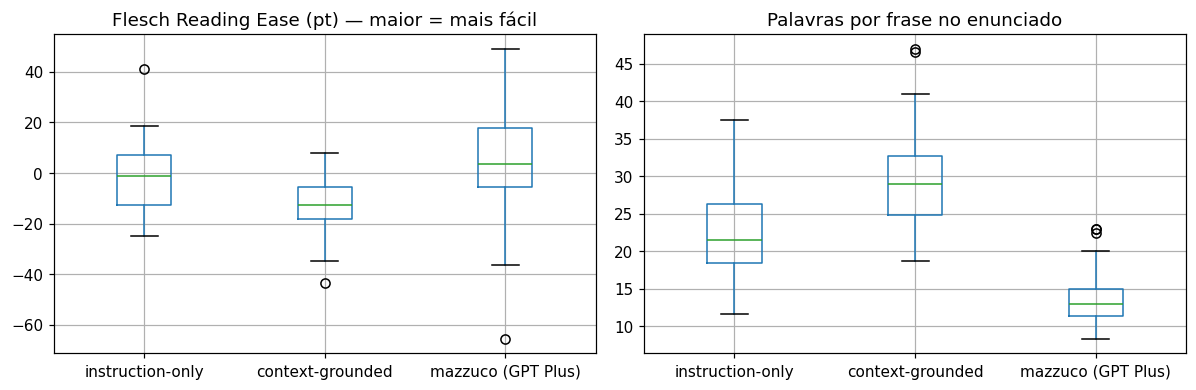

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
df_all.boxplot(column="flesch_reading_ease", by="grupo", ax=axes[0])
axes[0].set_title("Flesch Reading Ease (pt) — maior = mais fácil")
axes[0].set_xlabel("")

df_all.boxplot(column="palavras_por_frase", by="grupo", ax=axes[1])
axes[1].set_title("Palavras por frase no enunciado")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 9. Resumo consolidado

In [17]:
resumo = pd.concat([
    df_vocab[["MSTTR_300", "TTR_global"]],
    tam_summary,
    chuta_summary,
    distrator_summary,
    read_summary[["flesch_reading_ease", "palavras_por_frase"]],
], axis=1)
resumo

,MSTTR_300,TTR_global,pct_maior_e_correta,pct_menor_e_correta,razao_media,pct_correta_mais_similar,gap_semantico_medio,sim_media_correta_distratores,sim_minima_media,flesch_reading_ease,palavras_por_frase
grupo,,,,,,,,,,,
instruction-only,0.683,0.463,86.0,2.0,1.29,34.0,0.008,0.475,0.390,-1.59,22.39
context-grounded,0.680,0.383,66.7,5.9,1.14,27.5,0.017,0.511,0.435,-12.90,29.52
mazzuco (GPT Plus),0.753,0.394,21.9,26.9,0.99,30.6,0.018,0.421,0.323,5.43,13.27


## 10. Leitura dos resultados

- **Riqueza vocabular** (seção 3): MSTTR mais alto = vocabulário mais variado
  (menos repetição de fórmulas de enunciado) para um corpus de tamanho comparável.
- **Viés de tamanho** (seção 4): `pct_maior_e_correta` bem acima de 25% indica que
  dá para chutar a resposta pela alternativa mais longa, sem ler o conteúdo;
  `pct_menor_e_correta` bem acima de 25% indica o vício simétrico (chutar pela
  alternativa mais curta).
- **Chutabilidade** (seção 6): `pct_correta_mais_similar` acima de 25%, ou
  `gap_semantico_medio` bem positivo, indicam que o enunciado "vaza" a resposta
  por proximidade semântica.
- **Distratores** (seção 7): similaridade correta↔distratores muito baixa sugere
  distratores fáceis de eliminar por serem "fora do assunto"; similaridade muito
  alta pode indicar distratores quase corretos (questão ambígua) — o ideal fica
  numa faixa intermediária, não nos extremos.
- **Clareza** (seção 8): trate como sinal comparativo entre grupos, não como nota
  absoluta — ver ressalvas na seção 8.

Nenhuma dessas métricas substitui uma curadoria humana especializada; elas servem
para **priorizar** onde a revisão manual deve se concentrar.

## 11. Viés de posição do gabarito

Outro vício clássico de MCQ gerada por LLM: o gabarito cair desproporcionalmente
numa posição fixa (em geral "A", por ser a primeira alternativa escrita). Se a
posição do gabarito fosse independente do processo de geração, cada letra
deveria ser a correta em ~25% das questões.

grupo           instruction-only  context-grounded  mazzuco (GPT Plus)
gabarito_letra                                                        
A                           30.0              29.4                25.0
B                           30.0              29.4                25.0
C                           20.0              21.6                25.0
D                           20.0              19.6                25.0

      instruction-only: distribuição A/B/C/D = [15, 15, 10, 10]  |  qui-quadrado vs. uniforme p=0.572
      context-grounded: distribuição A/B/C/D = [15, 15, 11, 10]  |  qui-quadrado vs. uniforme p=0.653
    mazzuco (GPT Plus): distribuição A/B/C/D = [40, 40, 40, 40]  |  qui-quadrado vs. uniforme p=1.000


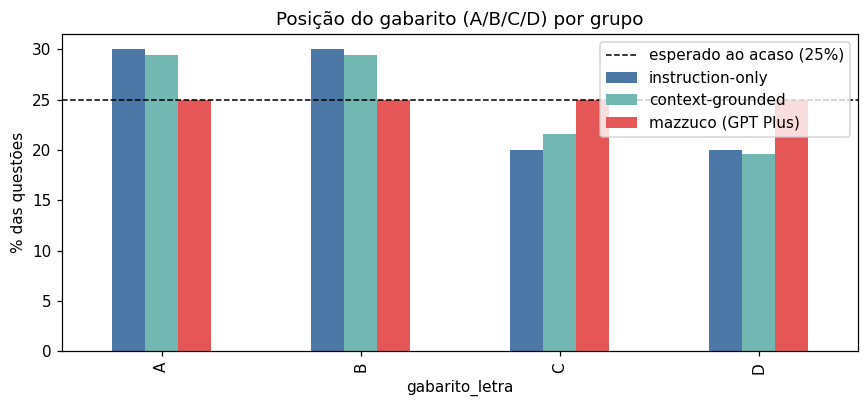

In [18]:
from scipy.stats import chisquare

LETTERS = ["A", "B", "C", "D"]
df_all["gabarito_letra"] = df_all["correct_answer_index"].map(dict(enumerate(LETTERS)))
df_all["gabarito_e_A"] = df_all["correct_answer_index"] == 0

pos_ct = pd.crosstab(df_all["gabarito_letra"], df_all["grupo"], normalize="columns").mul(100).round(1)
pos_ct = pos_ct.reindex(LETTERS)
print(pos_ct)
print()
for grupo, d in df_all.groupby("grupo", observed=True):
    obs = d["gabarito_letra"].value_counts().reindex(LETTERS, fill_value=0).to_numpy()
    chi2, p = chisquare(obs)
    print(f"{grupo:>22}: distribuição A/B/C/D = {obs.tolist()}  |  qui-quadrado vs. uniforme p={p:.3f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
pos_ct.plot(kind="bar", ax=ax, color=["#4c78a8", "#72b7b2", "#e45756"])
ax.axhline(25, color="k", ls="--", lw=1, label="esperado ao acaso (25%)")
ax.set_ylabel("% das questões")
ax.set_title("Posição do gabarito (A/B/C/D) por grupo")
ax.legend()
plt.tight_layout(); plt.show()

## 12. Comparação justa — amostra balanceada por tópico

As seções 1–11 usam **todas** as questões disponíveis: 50 (instruction-only),
51 (context-grounded) e 160 (mazzuco). Isso é problemático para uma comparação
honesta por dois motivos:

1. **Tamanho**: 160 vs. ~50 dá ao lote do Mazzuco muito mais peso nas médias
   agregadas e mais poder estatístico para detectar diferenças pequenas.
2. **Cobertura de tópico**: o Mazzuco só tem 4 dos 5 tópicos (não existe
   `gestao_desempenho` nos arquivos dele). Comparar médias globais mistura
   "efeito do processo de geração" com "efeito de quais tópicos entraram na
   conta" — um viés de confusão (*confounding*), não só um problema de N.

A correção aplicada aqui: restringir aos **tópicos presentes nos três grupos**
e sortear, **por grupo e por tópico**, o mesmo número de questões (o menor N
naturalmente disponível — instruction-only/context-grounded têm ~10 por
tópico), com seed fixa para reprodutibilidade. Isso equipara N *e* mix de
tópicos ao mesmo tempo.

In [19]:
FAIR_SEED = 42

COMMON_TOPICS = sorted(set(df_mazzuco["topic"]) & set(df_ins["topic"]) & set(df_ctx["topic"]))
print("Tópicos comuns aos 3 grupos:", COMMON_TOPICS)
print("Tópico(s) fora da comparação justa (não existem no Mazzuco):",
      sorted(set(df_ins["topic"]) - set(COMMON_TOPICS)))

df_common = df_all[df_all["topic"].isin(COMMON_TOPICS)].copy()
counts = df_common.groupby(["grupo", "topic"], observed=True).size().unstack()
print("\nQuestões disponíveis por (grupo, tópico):")
print(counts)

N_PER_TOPIC = int(counts.min().min())
print(f"\nN por (grupo, tópico) na amostra justa: {N_PER_TOPIC}  ->  "
      f"{N_PER_TOPIC * len(COMMON_TOPICS)} questões por grupo")

df_fair = (
    df_common.groupby(["grupo", "topic"], observed=True)
    .sample(n=N_PER_TOPIC, random_state=FAIR_SEED)
)
df_fair.groupby("grupo", observed=True).size()

Tópicos comuns aos 3 grupos: ['injecao_agua_mar', 'medicao_fiscal_offloading', 'produtos_quimicos', 'tratamento_agua_produzida']
Tópico(s) fora da comparação justa (não existem no Mazzuco): ['gestao_desempenho']

Questões disponíveis por (grupo, tópico):
topic               injecao_agua_mar  medicao_fiscal_offloading  \
grupo                                                             
instruction-only                  10                         10   
context-grounded                  10                         11   
mazzuco (GPT Plus)                40                         40   

topic               produtos_quimicos  tratamento_agua_produzida  
grupo                                                             
instruction-only                   10                         10  
context-grounded                   10                         10  
mazzuco (GPT Plus)                 40                         40  

N por (grupo, tópico) na amostra justa: 10  ->  40 questões por grupo


grupo
instruction-only      40
context-grounded      40
mazzuco (GPT Plus)    40
dtype: int64

In [20]:
vocab_fair_rows = []
for grupo, d in df_fair.groupby("grupo", observed=True):
    toks = [t for stem in d["stem"] for t in content_tokens(stem)]
    vocab_fair_rows.append({
        "grupo": grupo,
        "MSTTR_300": round(msttr(toks, 300), 3),
        "TTR_global": round(len(set(toks)) / max(len(toks), 1), 3),
    })
df_vocab_fair = pd.DataFrame(vocab_fair_rows).set_index("grupo")

agg_fair = df_fair.groupby("grupo", observed=True).agg(
    pct_maior_e_correta=("maior_e_correta", "mean"),
    pct_menor_e_correta=("menor_e_correta", "mean"),
    pct_gabarito_A=("gabarito_e_A", "mean"),
    pct_correta_mais_similar=("correta_e_mais_similar_ao_enunciado", "mean"),
    gap_semantico_medio=("gap_semantico", "mean"),
    sim_media_correta_distratores=("sim_correta_distratores_media", "mean"),
    flesch_reading_ease=("flesch_reading_ease", "mean"),
    palavras_por_frase=("palavras_por_frase", "mean"),
)
for c in ["pct_maior_e_correta", "pct_menor_e_correta", "pct_gabarito_A", "pct_correta_mais_similar"]:
    agg_fair[c] = (agg_fair[c] * 100).round(1)
for c in ["gap_semantico_medio", "sim_media_correta_distratores", "flesch_reading_ease", "palavras_por_frase"]:
    agg_fair[c] = agg_fair[c].round(3)

resumo_fair = pd.concat([df_vocab_fair, agg_fair], axis=1)
print(f"Resumo — amostra justa (N={N_PER_TOPIC * len(COMMON_TOPICS)}/grupo, tópicos comuns, seed={FAIR_SEED})")
resumo_fair

Resumo — amostra justa (N=40/grupo, tópicos comuns, seed=42)


,MSTTR_300,TTR_global,pct_maior_e_correta,pct_menor_e_correta,pct_gabarito_A,pct_correta_mais_similar,gap_semantico_medio,sim_media_correta_distratores,flesch_reading_ease,palavras_por_frase
grupo,,,,,,,,,,
instruction-only,0.674,0.477,87.5,0.0,30.0,27.5,-0.008,0.483,-1.211,22.898
context-grounded,0.672,0.390,62.5,5.0,30.0,25.0,0.008,0.512,-12.543,30.383
mazzuco (GPT Plus),0.788,0.657,20.0,30.0,25.0,45.0,0.011,0.429,4.066,12.946


### 12.1 As diferenças são estatisticamente robustas?

Nenhuma das seções anteriores testa se uma diferença entre grupos é maior do
que se esperaria por acaso — só compara médias/percentuais. Com N igualado
(seção 12), calculamos testes pareados por grupo:

- **Qui-quadrado** para as métricas binárias (maior_e_correta, gabarito_A,
  correta_mais_similar): o gabarito "acerta" a característica ou não.
- **Mann-Whitney U** para as métricas contínuas (gap_semantico,
  sim_correta_distratores): não assume distribuição normal, adequado para
  esses escores limitados entre -1 e 1.

p < 0.05 é usado como referência informal (não há correção para múltiplas
comparações — com ~8 testes, é razoável esperar 1 falso positivo por acaso;
trate valores próximos de 0.05 com cautela).

In [21]:
from itertools import combinations
from scipy.stats import mannwhitneyu, chi2_contingency

GRUPOS_ORDEM = ["instruction-only", "context-grounded", "mazzuco (GPT Plus)"]
pares = list(combinations(GRUPOS_ORDEM, 2))


def mw_p(col):
    out = {}
    for g1, g2 in pares:
        x = df_fair.loc[df_fair["grupo"] == g1, col]
        y = df_fair.loc[df_fair["grupo"] == g2, col]
        _, p = mannwhitneyu(x, y, alternative="two-sided")
        out[f"{g1} vs {g2}"] = round(p, 3)
    return out


def prop_chi2_p(col):
    out = {}
    for g1, g2 in pares:
        sub = df_fair[df_fair["grupo"].isin([g1, g2])]
        ct = pd.crosstab(sub["grupo"], sub[col])
        _, p, _, _ = chi2_contingency(ct)
        out[f"{g1} vs {g2}"] = round(p, 3)
    return out


sig = pd.DataFrame({
    "maior_e_correta (qui2)": prop_chi2_p("maior_e_correta"),
    "menor_e_correta (qui2)": prop_chi2_p("menor_e_correta"),
    "gabarito_A (qui2)": prop_chi2_p("gabarito_e_A"),
    "correta_mais_similar (qui2)": prop_chi2_p("correta_e_mais_similar_ao_enunciado"),
    "gap_semantico (Mann-Whitney)": mw_p("gap_semantico"),
    "sim_correta_distratores (Mann-Whitney)": mw_p("sim_correta_distratores_media"),
})
sig

,maior_e_correta (qui2),menor_e_correta (qui2),gabarito_A (qui2),correta_mais_similar (qui2),gap_semantico (Mann-Whitney),sim_correta_distratores (Mann-Whitney)
instruction-only vs context-grounded,0.02,0.474,1.000,1.000,0.560,0.076
instruction-only vs mazzuco (GPT Plus),0.00,0.001,0.802,0.163,0.389,0.132
context-grounded vs mazzuco (GPT Plus),0.00,0.008,0.802,0.101,0.683,0.001


## 13. Concentração semântica dos embeddings por tema

Pergunta: dentro de um mesmo tema, as questões de um grupo ficam muito
"parecidas" entre si no espaço de embeddings (indício de geração repetitiva/
template) ou são bem espalhadas (indício de maior diversidade de enfoque)?

Métrica: **similaridade de cosseno média entre pares** de embeddings de
enunciado, calculada dentro de cada (grupo, tópico). Quanto mais próxima de 1,
mais concentradas/redundantes as questões daquele grupo naquele tema; valores
mais baixos indicam enunciados mais diversos entre si. Diferente do TTR
(seção 3), essa métrica não é mecanicamente sensível ao tamanho do grupo — mas
com poucos itens (ex.: 10) o valor é mais ruidoso do que com 40, então leia com
cautela.

grupo                      instruction-only  context-grounded  \
topic                                                           
injecao_agua_mar                      0.613             0.796   
medicao_fiscal_offloading             0.664             0.779   
produtos_quimicos                     0.685             0.795   
tratamento_agua_produzida             0.713             0.786   

grupo                      mazzuco (GPT Plus)  
topic                                          
injecao_agua_mar                        0.485  
medicao_fiscal_offloading               0.420  
produtos_quimicos                       0.502  
tratamento_agua_produzida               0.469  


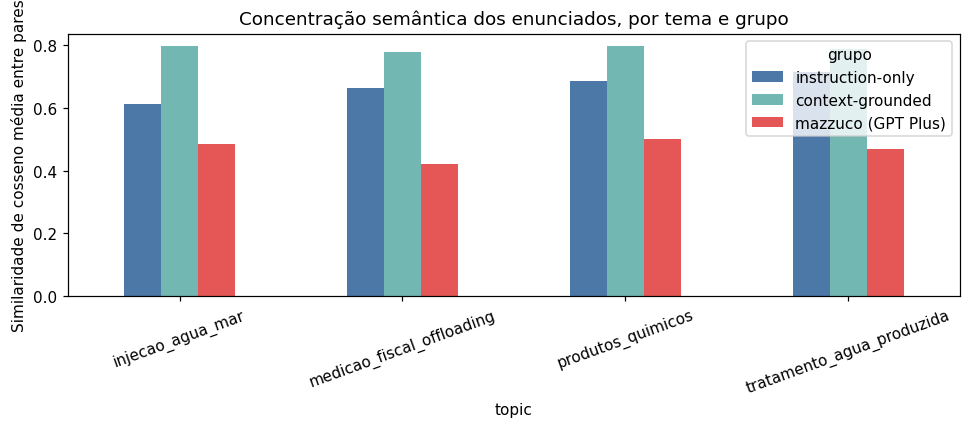

In [22]:
def mean_pairwise_sim(embs):
    if len(embs) < 2:
        return np.nan
    sim = cosine_similarity(embs)
    iu = np.triu_indices_from(sim, k=1)
    return float(sim[iu].mean())


conc_rows = []
for (grupo, topic), d in df_common.groupby(["grupo", "topic"], observed=True):
    embs = stem_emb[d.index]
    conc_rows.append({"grupo": grupo, "topic": topic, "n": len(d), "sim_par_media": mean_pairwise_sim(embs)})
df_conc = pd.DataFrame(conc_rows)
conc_pivot = df_conc.pivot(index="topic", columns="grupo", values="sim_par_media")[GRUPOS_ORDEM].round(3)
print(conc_pivot)

fig, ax = plt.subplots(figsize=(9, 4))
conc_pivot.plot(kind="bar", ax=ax, color=["#4c78a8", "#72b7b2", "#e45756"])
ax.set_ylabel("Similaridade de cosseno média entre pares")
ax.set_title("Concentração semântica dos enunciados, por tema e grupo")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### 13.1 Inspeção visual — um tema específico

A tabela acima resume em um número, mas é fácil enganar o olho com médias.
Escolhemos automaticamente o tema com **maior variação** de concentração entre
os 3 grupos (o caso mais "interessante" de checar visualmente) e projetamos os
embeddings dos enunciados desse tema em 2D via PCA (ajustado só com os pontos
desse tema, para não achatar a estrutura local sob a variância entre temas).
Pontos próximos = enunciados semanticamente parecidos.

Tópico escolhido (maior variação de concentração entre grupos): medicao_fiscal_offloading


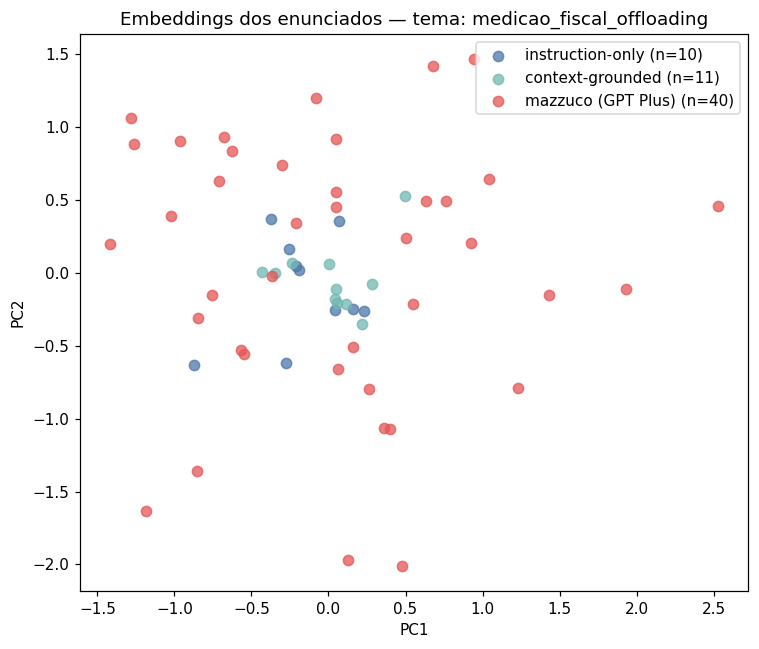

In [23]:
from sklearn.decomposition import PCA

COLORS = {"instruction-only": "#4c78a8", "context-grounded": "#72b7b2", "mazzuco (GPT Plus)": "#e45756"}

topic_deep_dive = (conc_pivot.max(axis=1) - conc_pivot.min(axis=1)).idxmax()
print("Tópico escolhido (maior variação de concentração entre grupos):", topic_deep_dive)

d_topic = df_common[df_common["topic"] == topic_deep_dive]
embs_topic = stem_emb[d_topic.index]
coords = PCA(n_components=2, random_state=42).fit_transform(embs_topic)

fig, ax = plt.subplots(figsize=(7, 6))
for grupo, color in COLORS.items():
    mask = (d_topic["grupo"] == grupo).to_numpy()
    if mask.sum() == 0:
        continue
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f"{grupo} (n={mask.sum()})",
               color=color, alpha=0.75, s=45)
ax.set_title(f"Embeddings dos enunciados — tema: {topic_deep_dive}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout(); plt.show()

### 13.2 Todos os temas, todas as questões (Mazzuco podado)

Mesma ideia acima, mas para **todos os temas de uma vez**, em um grid de
pequenos múltiplos (um PCA local por tema). `instruction-only` e
`context-grounded` entram com todas as suas questões (incluindo
`gestao_desempenho`, que não existe no Mazzuco — por isso esse painel não terá
pontos vermelhos). O Mazzuco entra **podado** para o mesmo N por tema usado na
amostra justa da seção 12 (mesma seed), para não dominar visualmente o gráfico
só por ter 4x mais questões por tema.

grupo
instruction-only      50
context-grounded      51
mazzuco (GPT Plus)    40
dtype: int64


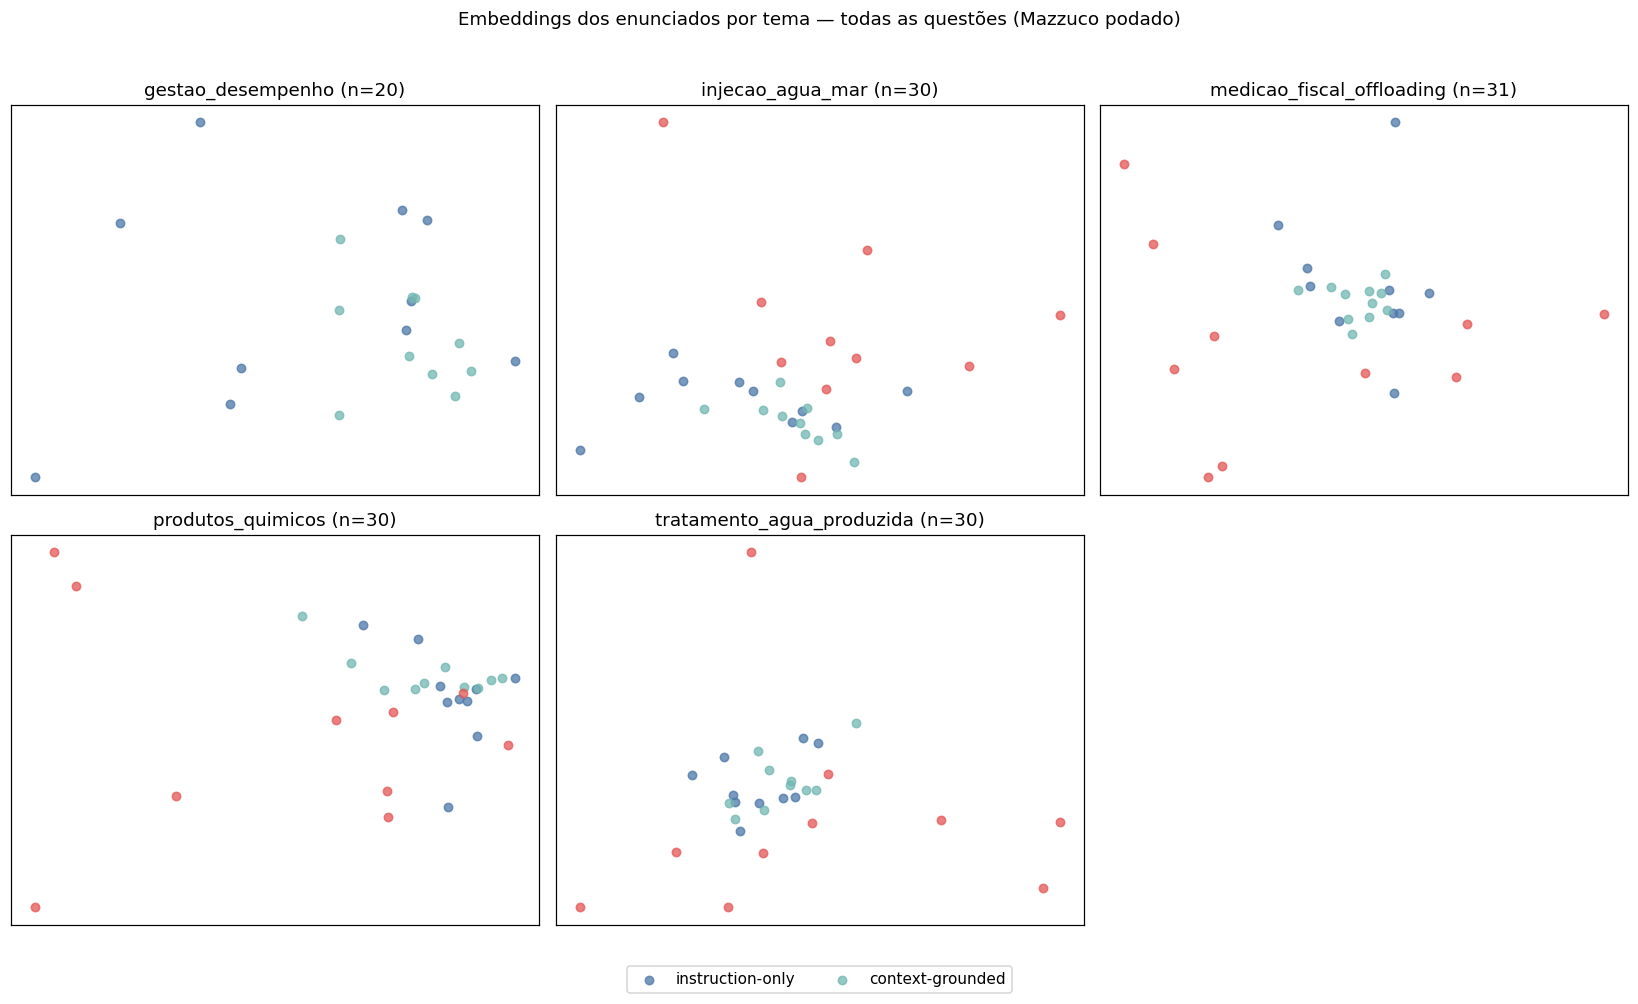

In [24]:
df_global_pruned = pd.concat([
    df_all[df_all["grupo"] == "instruction-only"],
    df_all[df_all["grupo"] == "context-grounded"],
    df_fair[df_fair["grupo"] == "mazzuco (GPT Plus)"],  # Mazzuco podado a N_PER_TOPIC/tema
])
print(df_global_pruned.groupby("grupo", observed=True).size())

topics_all = sorted(df_global_pruned["topic"].unique())
ncols = 3
nrows = int(np.ceil(len(topics_all) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, topic in zip(axes, topics_all):
    d_t = df_global_pruned[df_global_pruned["topic"] == topic]
    embs_t = stem_emb[d_t.index]
    coords_t = PCA(n_components=2, random_state=42).fit_transform(embs_t)
    for grupo, color in COLORS.items():
        mask = (d_t["grupo"] == grupo).to_numpy()
        if mask.sum() == 0:
            continue
        ax.scatter(coords_t[mask, 0], coords_t[mask, 1], label=grupo, color=color, alpha=0.75, s=30)
    ax.set_title(f"{topic} (n={len(d_t)})")
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(topics_all):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Embeddings dos enunciados por tema — todas as questões (Mazzuco podado)")
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

## 14. Leitura dos resultados (seções 11–13)

- **Posição do gabarito** (seção 11): após a correção do parser (nota na seção 1),
  o Mazzuco **não** mostra viés de posição — distribuição perfeitamente uniforme
  (40/40/40/40, qui-quadrado p=1.000). instruction-only e context-grounded também
  ficam estatisticamente indistinguíveis do acaso (p=0.572 e p=0.653). O achado
  anterior de "~44% para a letra A, p<0.001" era um artefato do bug de parsing, não
  um vício real de curadoria.
- **Amostra justa N=40/tópicos comuns** (seção 12): ao equiparar N e mix de
  tópicos, o viés de tamanho (`pct_maior_e_correta`) segue alto em
  instruction-only/context-grounded (87,5% e 62,5%) e significativamente diferente
  do Mazzuco (20,0%) nos três pares — essa conclusão é robusta e não dependia do
  bug corrigido. `pct_gabarito_A` e `pct_correta_mais_similar`, que pareciam
  distinguir os grupos na base completa (seções 4 e 6), seguem **não
  significativos** com N igualado.
- **Viés de tamanho, direção "mais curta"** (`pct_menor_e_correta`, seção 4/12):
  em instruction-only e context-grounded a alternativa mais curta é a correta
  em praticamente 0% das questões (0,0% e 5,0% na amostra justa) — bem abaixo
  do 25% esperado ao acaso, e as duas pipelines não são significativamente
  diferentes entre si (p=0,474). Ou seja, o viés de tamanho dessas duas
  pipelines é **assimétrico**: ele empurra o gabarito para a alternativa mais
  longa, quase nunca para a mais curta. No Mazzuco (já com o gabarito corrigido)
  a mais curta é a correta em 30% das questões e a mais longa em só 20% — os
  dois valores próximos do acaso (25%) e estatisticamente diferentes das outras
  duas pipelines (p≤0,008) — ou seja, o Mazzuco não mostra viés de tamanho
  relevante em nenhuma das duas direções.
- **Concentração semântica** (seção 13): resultado mais claro do notebook —
  dentro do mesmo tema, instruction-only e sobretudo context-grounded têm
  similaridade de par muito mais alta (~0.67–0.80) que o Mazzuco (~0.42–0.50)
  em todos os 4 tópicos comuns, e o mesmo padrão aparece no grid com todas as
  questões. Isso é visível a olho nu no scatter da seção 13.1: os pontos
  azuis/verdes formam um núcleo apertado, os vermelhos se espalham pelo plano.
  Interpretação: as duas pipelines próprias produzem questões mais parecidas
  entre si dentro de um mesmo tema — risco de baixa diversidade de enfoque,
  mesmo quando o vocabulário (seção 3) parece rico.

Nenhuma dessas métricas substitui curadoria humana — servem para **priorizar**
onde revisar e para não tirar conclusões de comparações com N ou cobertura de
tópico desiguais.